<a href="https://colab.research.google.com/github/LucasCttr/animal-clustering-analysis/blob/main/Ciencia_de_Datos_Trabajo_pr%C3%A1ctico_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 2

## Problema

Un conjunto de investigadores poseen una base de datos de distintos animales con distintas
características. Los investigadores desean explorar el conjunto de datos para encontrar tipos de
animales que compartan características en común y que permitan su estudio de forma más
segmentada. Asimismo, se desea obtener una descripción de los mismos para poder asignar los
individuos a investigadores especializados.
El conjunto de datos ya se encuentra limpio, y no resulta necesaria en esta instancia realizar un
estudio de calidad de los mismos.
Los atributos que intervienen son: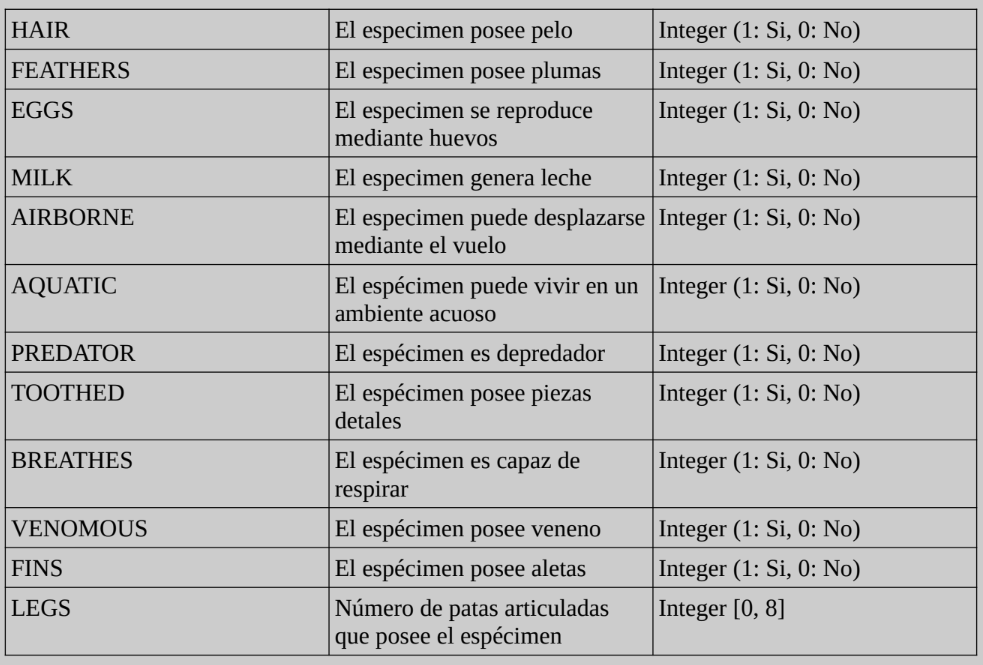

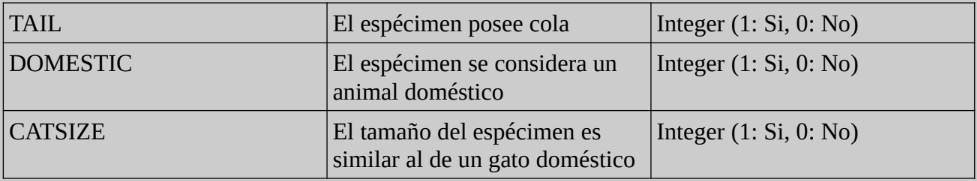

## Condiciones de entrega


- Presentar un archivo .zip o un repositorio git con el código del projecto y los reportes.

- No resulta necesario en esta entrega utilizar CRISP-DM en su totalidad, mas se debe
documentar el proceso, incluyendo objetivos de minería de datos. El projecto debe estar
bien documentado, no solo aplicando código, sino también justificando las decisiones que se
tomen. Los notebooks deben ser bien descriptivos.

- La estructura del proyecto queda a cargo del alumno. Desde la cátedra sugerimos, por fines
de simplicidad, utilizar un único archivo .ipynb (jupyter notebook) donde, a través de títulos,
se evidencie todo el proceso llevado a cabo.

- El o los algoritmos a utilizar quedan a cargo de los alumnos. La elección deberá estar
debidamente justificada.

- El número de grupos a generar queda a consideración de los alumnos, al ser parte del
problema. Se deberá investigar métricas de calidad de los grupos con este fin. Utilizar un
procedimiento sistemático para evaluar estas métricas.

- Considerar si resulta necesaria la preparación de los datos.

- Brindar una o varias respuestas a la demanda de los clientes, utilizando las herramientas que
conocen.

- Presentar un reporte de negocio adicional, en pdf, con los hallazgos. Esto deberá ser
realizado en un lenguaje apropiado para el negocio, por lo que lenguaje técnico deberá ser
omitido. Pónganse en el lugar del comitente y preguntensé: ¿podrá entender esto que estoy
escribiendo? ¿le va a servir esta información para tomar decisiones?

# 1. Entendimiento del negocio

## Objetivos del negocio
Permitir a los investigadores segmentar el conjunto de animales según características comunes, para:

1. Asignar cada grupo a especialistas adecuados.

2. Facilitar estudios focalizados y colaborativos.

3. Mejorar la organización de la base de conocimiento zoológico

Además, proveer una forma clara para asignar nuevos individuos a grupos individuales.

**Objetivo de éxito del negocio:**

Que los investigadores consideren que las agrupaciones son coherentes y útiles para su trabajo (por ejemplo, que cada especialista pueda reconocer patrones relevantes dentro de su campo).

## Objetivos de minería de datos

Identificar patrones de similitud entre animales mediante técnicas de clustering, sin etiquetas previas, para descubrir grupos internamente homogéneos y externamente distintos.

**Objetivos de éxito de minería de datos**

1. Obtener un modelo de agrupamiento con alta cohesión intra-clúster y alta separación inter-clúster (evaluado con metrica silhouette).

2. Lograr una interpretación clara de cada grupo en función de los atributos más influyentes.

3. Lograr un indice silhouette mayor a 0,5.

4. Lograr un accuracy mayor a 0.6 para el modelo clasificador.

# 2. Entendimiento de los datos




Descargamos la database a utilizar

In [ ]:
!pip install gdown prince
import gdown
import pandas as pd

file_id = '1VTnnHk5TnITqpyU7Winhvifomr3yokFe'
output = 'survey-490b.csv'

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1VTnnHk5TnITqpyU7Winhvifomr3yokFe
To: /content/survey-490b.csv
100%|██████████| 6.58k/6.58k [00:00<00:00, 15.5MB/s]


'survey-490b.csv'

In [ ]:
import pandas as pd
df = pd.read_csv('survey-490b.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   HAIR      101 non-null    float64
 1   FEATHERS  101 non-null    float64
 2   EGGS      101 non-null    float64
 3   MILK      101 non-null    float64
 4   AIRBORNE  101 non-null    float64
 5   AQUATIC   101 non-null    float64
 6   PREDATOR  101 non-null    float64
 7   TOOTHED   101 non-null    float64
 8   BACKBONE  101 non-null    float64
 9   BREATHES  101 non-null    float64
 10  VENOMOUS  101 non-null    float64
 11  FINS      101 non-null    float64
 12  LEGS      101 non-null    float64
 13  TAIL      101 non-null    float64
 14  DOMESTIC  101 non-null    float64
 15  CATSIZE   101 non-null    float64
dtypes: float64(16)
memory usage: 12.8 KB


Realizamos una breve visualizacion de los datos para entenderlos mejor

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


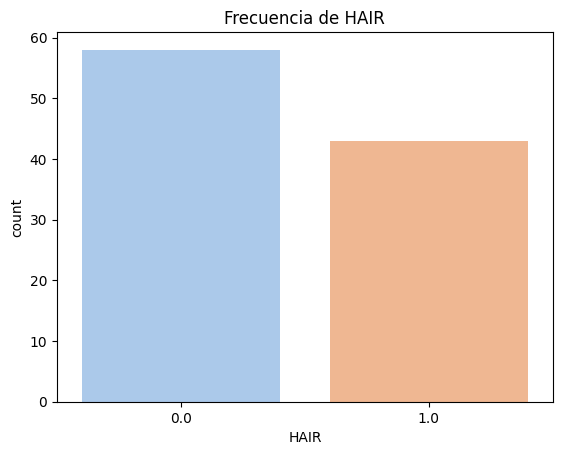

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


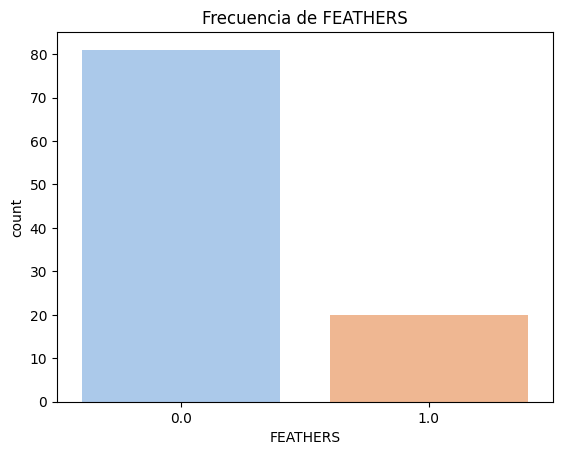

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


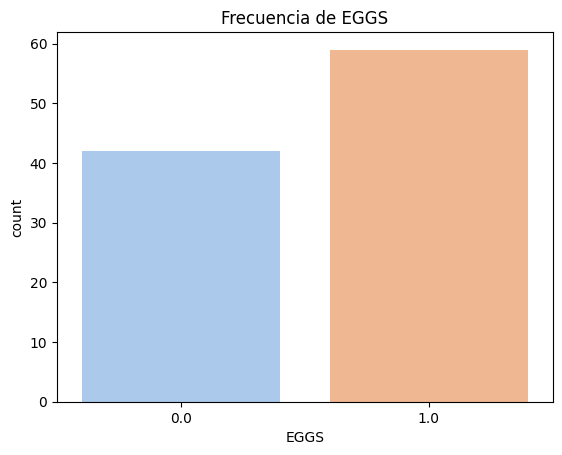

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


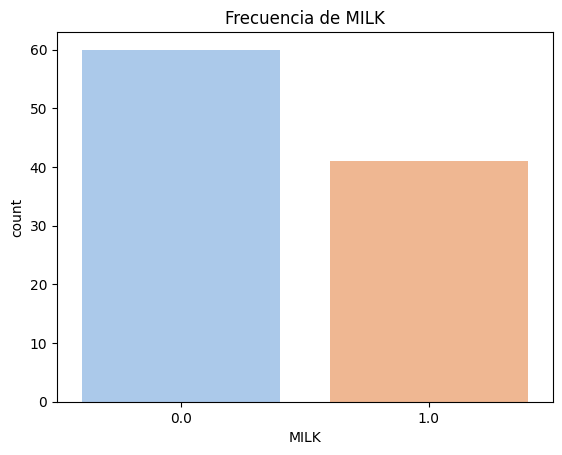

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


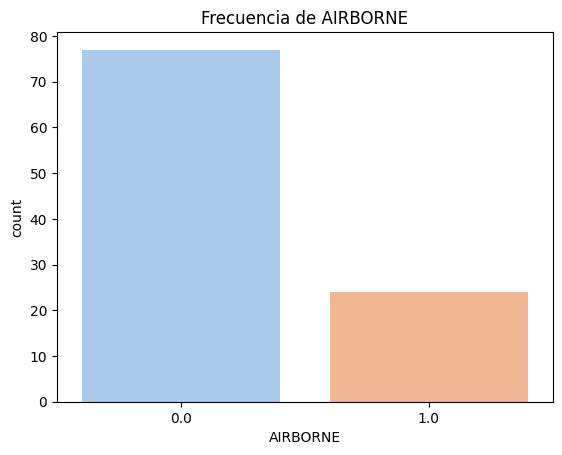

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


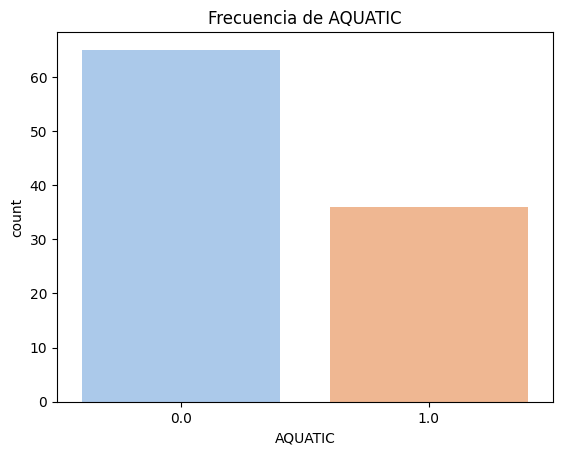

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


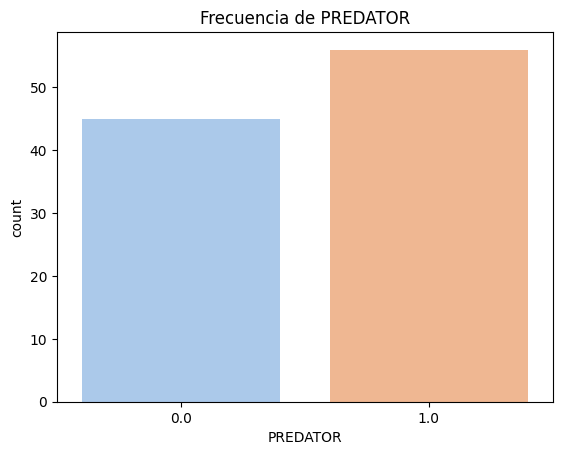

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


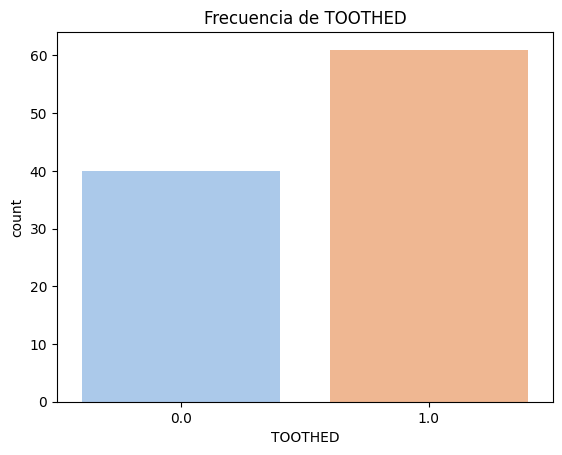

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


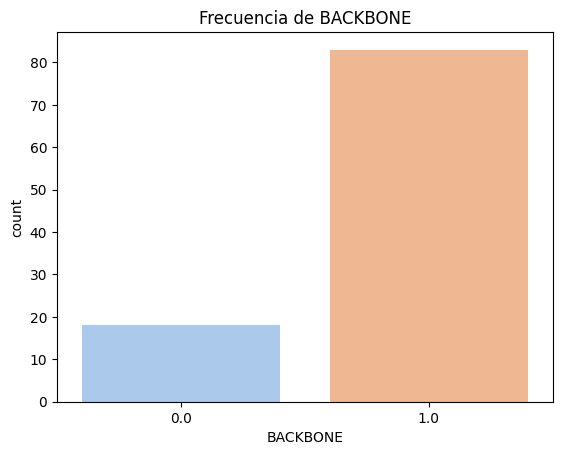

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


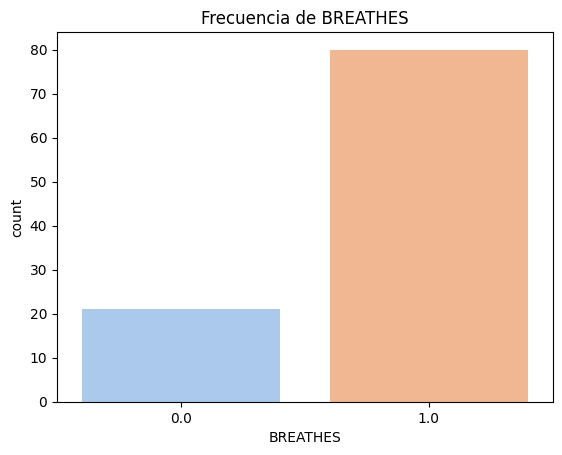

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


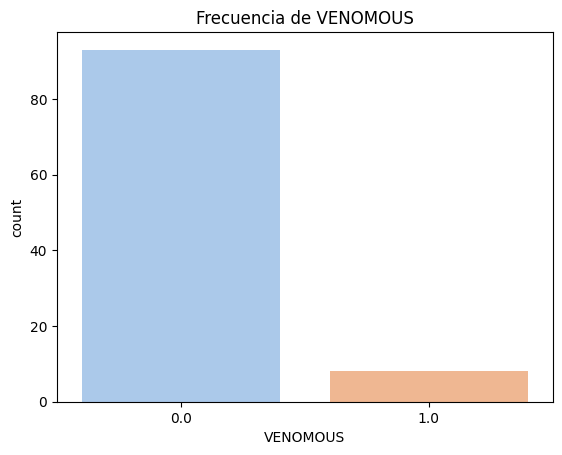

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


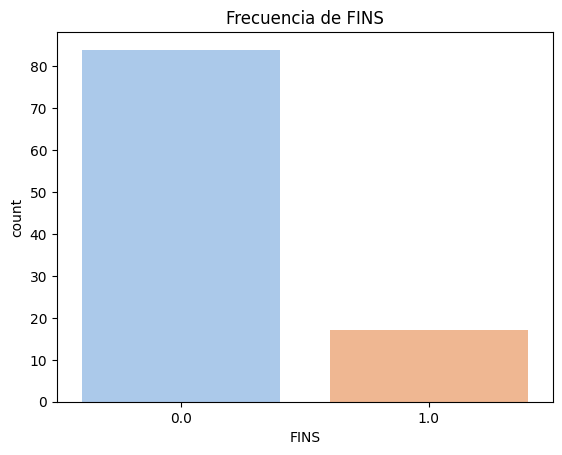

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


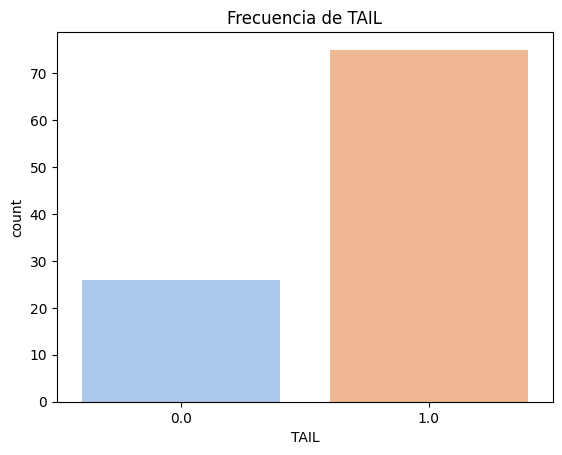

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


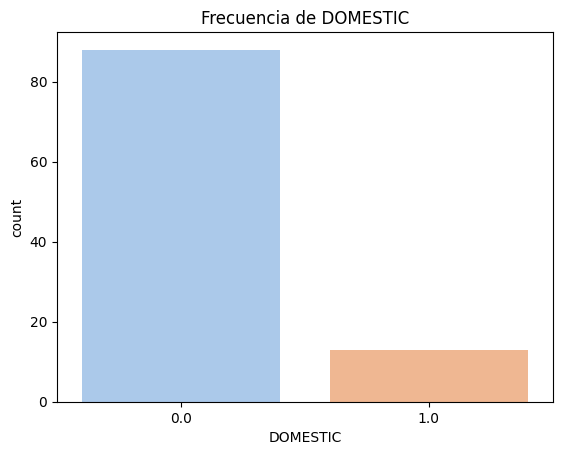

/tmp/ipython-input-2164768255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


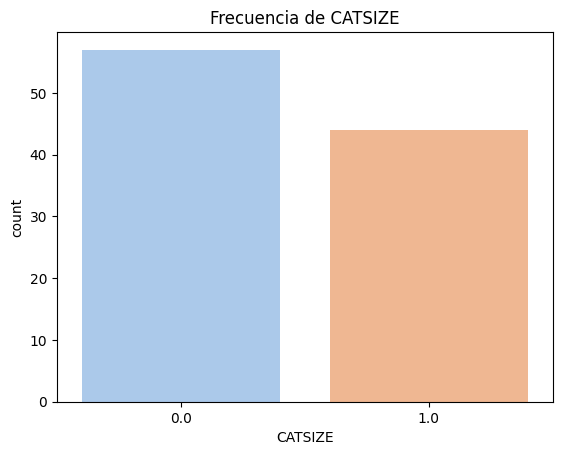

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

binarios = df.drop(columns=['LEGS'])  # si LEGS no es binario
for col in binarios.columns:
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Frecuencia de {col}')
    plt.show()


Número de patas y su frecuencia

In [ ]:
df["LEGS"].value_counts()

,count
LEGS,
4.0,38
2.0,27
0.0,23
6.0,10
8.0,2
5.0,1


In [ ]:
df.drop(columns=['LEGS'])  # Excluimos LEGS por ser numérica (Jaccard solo sirve para vectores binarios)

,HAIR,FEATHERS,EGGS,MILK,AIRBORNE,AQUATIC,PREDATOR,TOOTHED,BACKBONE,BREATHES,VENOMOUS,FINS,TAIL,DOMESTIC,CATSIZE
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
97,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
98,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
99,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'Animales en espacio reducido (MCA)')

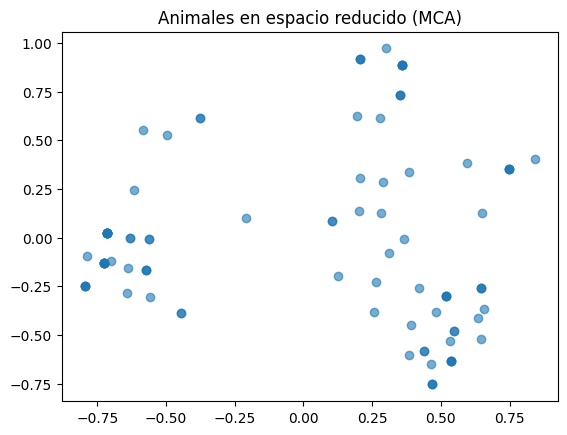

In [ ]:
# Al ser variables categóricas utilizamos MCA (Análisis de Correspondencias Múltiples) para
# visualizar la estructura del dataset
from prince import MCA
mca = MCA(n_components=2, random_state=42)
mca_coords = mca.fit_transform(df.drop(columns=['LEGS']))

# Visualizar clusters potenciales
plt.scatter(mca_coords[0], mca_coords[1], alpha=0.6)
plt.title("Animales en espacio reducido (MCA)")


Visualizacion de atributos correlacionados. (Matriz de correlaciones)

In [ ]:
df.corr()

,HAIR,FEATHERS,EGGS,MILK,AIRBORNE,AQUATIC,PREDATOR,TOOTHED,BACKBONE,BREATHES,VENOMOUS,FINS,LEGS,TAIL,DOMESTIC,CATSIZE
HAIR,1.000000,-0.427851,-0.817382,0.878503,-0.198431,-0.473554,-0.154769,0.492531,0.191681,0.441149,-0.104245,-0.280313,0.394009,0.048973,0.207208,0.455020
FEATHERS,-0.427851,1.000000,0.419248,-0.410761,0.656553,-0.058552,-0.104430,-0.613631,0.231403,0.254588,-0.145739,-0.223541,-0.206686,0.292569,0.031586,-0.135934
EGGS,-0.817382,0.419248,1.000000,-0.938848,0.376646,0.376244,0.011605,-0.642150,-0.340420,-0.382777,0.098689,0.164796,-0.224918,-0.221090,-0.155610,-0.514650
MILK,0.878503,-0.410761,-0.938848,1.000000,-0.366765,-0.362613,-0.029721,0.628168,0.384958,0.423527,-0.242449,-0.156328,0.214196,0.210026,0.163928,0.574906
AIRBORNE,-0.198431,0.656553,0.376646,-0.366765,1.000000,-0.172638,-0.295181,-0.594311,-0.104718,0.286039,0.008528,-0.251157,0.043712,0.009482,0.063274,-0.349768
AQUATIC,-0.473554,-0.058552,0.376244,-0.362613,-0.172638,1.000000,0.375978,0.053150,0.022463,-0.637506,0.087915,0.604492,-0.360638,-0.034642,-0.224308,-0.111866
PREDATOR,-0.154769,-0.104430,0.011605,-0.029721,-0.295181,0.375978,1.000000,0.129452,0.051022,-0.262931,0.115391,0.190302,-0.099723,0.018947,-0.309794,0.144790
TOOTHED,0.492531,-0.613631,-0.642150,0.628168,-0.594311,0.053150,0.129452,1.000000,0.575085,-0.065690,-0.062344,0.364292,-0.193476,0.310368,0.069430,0.344010
BACKBONE,0.191681,0.231403,-0.340420,0.384958,-0.104718,0.022463,0.051022,0.575085,1.000000,0.207666,-0.246611,0.209499,-0.432856,0.731762,0.101733,0.356976
BREATHES,0.441149,0.254588,-0.382777,0.423527,0.286039,-0.637506,-0.262931,-0.065690,0.207666,1.000000,-0.120752,-0.617219,0.369868,0.088952,0.124068,0.204125


No consideramos necesaria la preparación de datos mas allá de eliminar una columna, ya que la calidad de los datos era suficiente para arrancar con el análisis.

# 2. Preparacion de los datos

El dataframe ya se encuentra casi en su totalidad en formato binario; no se debio efectuar ninguna preparacion adicional, salvo por la columna "LEGS". En un principio se evaluo crear una columna por cada valor unico en esta, pero el resultado fueron valores menores en las metricas utilizadas por lo cual se decidio excluirla en el proceso de agrupamiento.

In [ ]:
X = df.drop(columns=['LEGS'])  # Excluimos LEGS por ser numérica (Jaccard solo sirve para vectores binarios)


# 3. Modelado

Para elegir el método de clustering, primero hay que considerar la forma esperada de los grupos. Si los clusters son aproximadamente esféricos, K-means suele funcionar bien. Sin embargo, los métodos jerárquicos no requieren parámetros como la cantidad de grupos y permiten explorar distintas particiones sin necesidad de fijar un k inicial, aunque tienen la limitación de no poder revertir decisiones una vez tomadas.
Por otro lado, DBSCAN exige definir dos parámetros (ε y minPts), puede detectar clusters de forma arbitraria y aislar ruido, pero presenta dificultades en zonas con densidad variable. Los métodos basados en grilla también podrían aplicarse, aunque no se espera un gran rendimiento con ellos.

En nuestro caso, no se nos proporciona la cantidad de grupos y tampoco es fácilmente deducible del dataset, por lo que descartamos los métodos de partición como punto de partida. En principio, la elección se reduce a métodos jerárquicos y DBSCAN, seleccionando el mejor en base a la medida Silhouette.

Decidimos comenzar con clustering jerárquico, dado que la base posee una estructura binaria, una baja cantidad de registros, y este tipo de métodos no requiere datos continuos ni normalizados. Además, permite utilizar métricas adecuadas a la naturaleza de los datos, como la distancia de Jaccard, que se enfoca en las coincidencias de presencia representadas por los valores 0 y 1.

Fuente utilizada: https://myweb.sabanciuniv.edu/rdehkharghani/files/2016/02/The-Morgan-Kaufmann-Series-in-Data-Management-Systems-Jiawei-Han-Micheline-Kamber-Jian-Pei-Data-Mining.-Concepts-and-Techniques-3rd-Edition-Morgan-Kaufmann-2011.pdf

## Jerarquía

Calculamos la matriz de disimilitud con Jaccard

In [ ]:
from scipy.spatial.distance import pdist, squareform

dist_matrix = pdist(X, metric='jaccard')       # Vector de distancias
dist_square = squareform(dist_matrix)          # Matriz de distancias cuadrada

Generación del dendograma.

Nos muestra la estructura completa del agrupamiento, antes de decidir cuántos clusters vamos a utilizar.

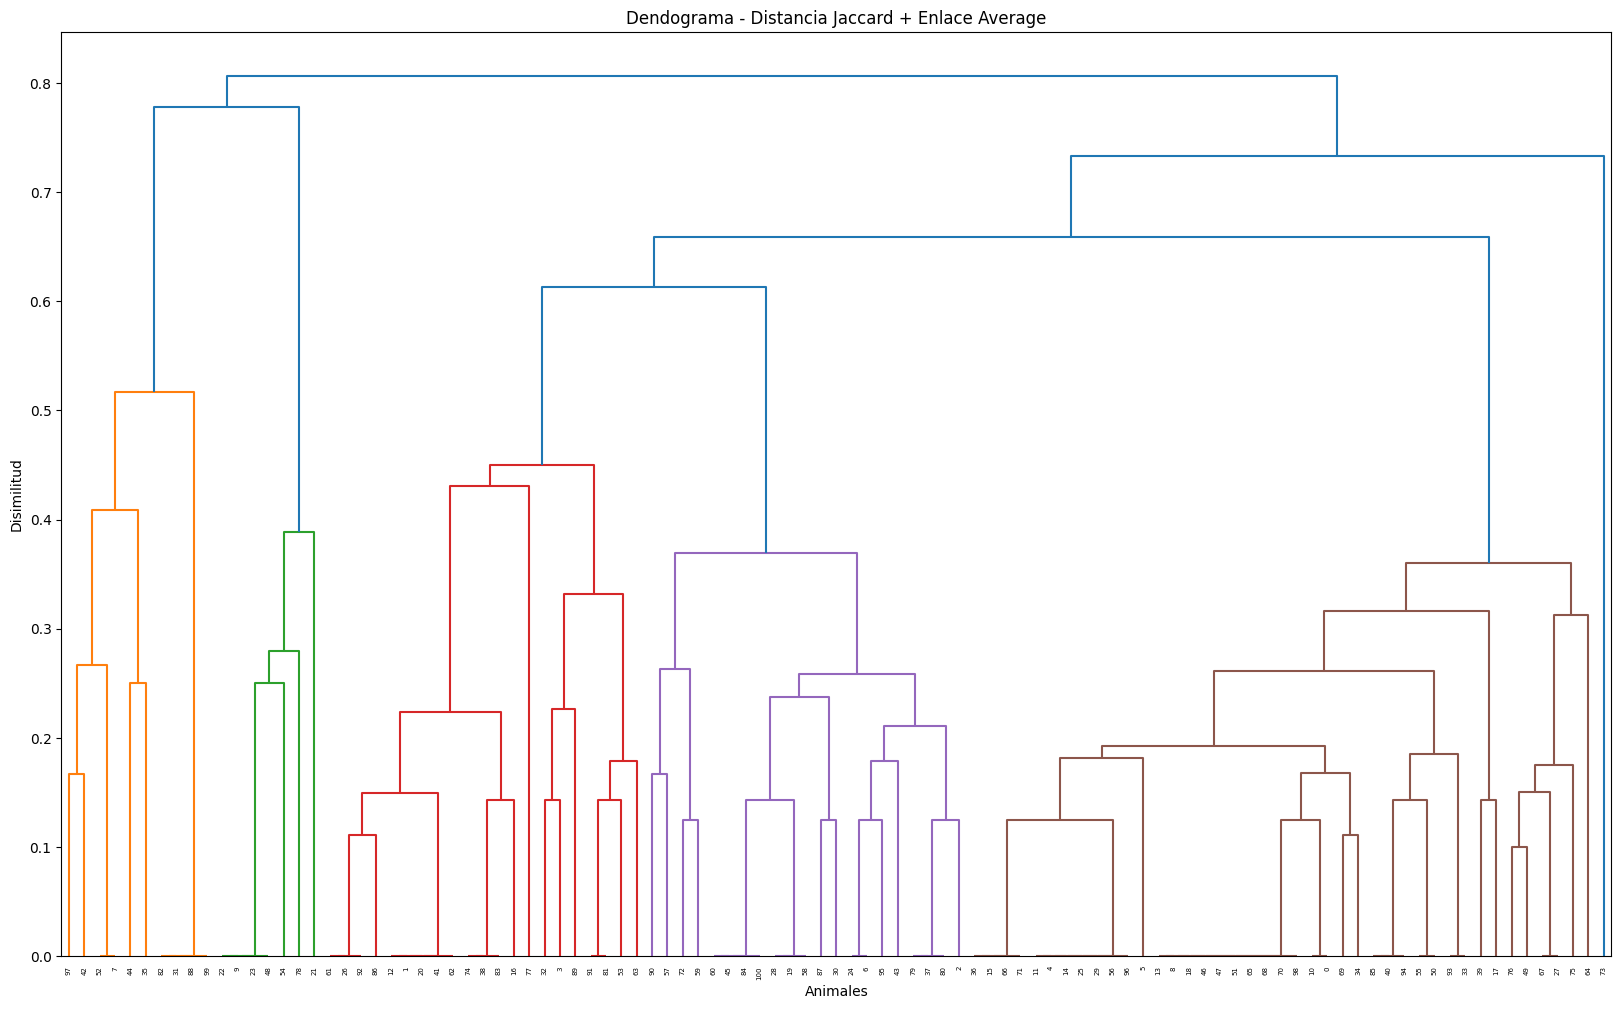

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(dist_matrix, method='average')  # También podés probar 'complete'

plt.figure(figsize=(20, 12))
dendrogram(linked, labels=df.index, orientation='top', distance_sort='descending')
plt.title('Dendograma - Distancia Jaccard + Enlace Average')
plt.xlabel('Animales')
plt.ylabel('Disimilitud')
plt.show()


Cortes del dendograma y evaluación.

Evalúa qué tan bien separados y cohesionados están los grupos en base a distintos valores de k.

In [ ]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 7):
    labels = fcluster(linked, k, criterion='maxclust')
    score = silhouette_score(dist_square, labels, metric='precomputed')
    resultados.append({'k': k, 'Silhouette': score})

pd.DataFrame(resultados)


,k,Silhouette
0,2,0.346167
1,3,0.341652
2,4,0.300247
3,5,0.459326
4,6,0.545568


Asignamos cada animal a su grupo, utilizamos el valor k=6 ya que fue el que mejor puntaje tuvo en el paso anterior.

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Cortamos el dendograma en k=6 (el óptimo según Silhouette)
labels = fcluster(linked, 6, criterion='maxclust')

# Agregamos los labels al DataFrame original
hierarchical_df = df.copy()
hierarchical_df["Grupo"] = labels

Cantidad de animales por grupo

In [ ]:
hierarchical_df["Grupo"].value_counts().sort_index()

,count
Grupo,
1,41
2,21
3,21
4,1
5,7
6,10


Visualizacion de los atributos de cada animal y el grupo al que fue asignado.

In [ ]:
hierarchical_df.sort_values('Grupo')

,HAIR,FEATHERS,EGGS,MILK,AIRBORNE,AQUATIC,PREDATOR,TOOTHED,BACKBONE,BREATHES,VENOMOUS,FINS,LEGS,TAIL,DOMESTIC,CATSIZE,Grupo
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,0.0,0.0,1.0,1
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,1.0,1
5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,1.0,1
15,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,1.0,1.0,1
13,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,6
82,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6
88,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,6
97,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,6.0,0.0,0.0,0.0,6


Perfil promedio de cada grupo.

Utilizamos estos valores para redactar en el informe las similitudes de los animales en cada grupo.

In [ ]:
hierarchical_df.groupby('Grupo').mean().round(2)

,HAIR,FEATHERS,EGGS,MILK,AIRBORNE,AQUATIC,PREDATOR,TOOTHED,BACKBONE,BREATHES,VENOMOUS,FINS,LEGS,TAIL,DOMESTIC,CATSIZE
Grupo,,,,,,,,,,,,,,,,
1,0.95,0.00,0.02,1.0,0.05,0.15,0.54,0.98,1.0,1.00,0.00,0.10,3.37,0.85,0.20,0.78
2,0.00,0.95,1.00,0.0,0.76,0.29,0.43,0.00,1.0,1.00,0.00,0.00,2.10,1.00,0.14,0.33
3,0.00,0.00,0.95,0.0,0.00,0.86,0.76,1.00,1.0,0.33,0.19,0.62,0.95,0.86,0.05,0.19
4,0.00,0.00,0.00,0.0,0.00,0.00,1.00,0.00,0.0,1.00,1.00,0.00,8.00,1.00,0.00,0.00
5,0.00,0.00,1.00,0.0,0.00,0.86,1.00,0.00,0.0,0.00,0.14,0.00,4.14,0.00,0.00,0.14
6,0.40,0.00,1.00,0.0,0.60,0.00,0.10,0.00,0.0,1.00,0.20,0.00,4.80,0.00,0.10,0.00


## Densidad

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid
import numpy as np

# Usamos los mismos datos X (datos binarios preparados)
# DBSCAN con ajuste de parámetros usando ParameterGrid
param_grid = {
    'eps': [0.1, 0.2, 0.4, 0.5, 0.6, 0.7],
    'min_samples': [2, 3, 4, 5]
}

best_score = -1
best_params = None
best_labels = None

for params in ParameterGrid(param_grid):
    dbscan = DBSCAN(metric='hamming', **params)
    labels = dbscan.fit_predict(X)
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):  # Más de un cluster y no todos ruido
        score = silhouette_score(X, labels, metric='hamming')
        if score > best_score:
            best_score = score
            best_params = params
            best_labels = labels

if best_params:
    print(f'Mejores parámetros: {best_params}')
    print(f'Silhouette Score for DBSCAN: {best_score:.3f}')
    labels_db = best_labels

    # Mostrar número de clusters y puntos de ruido
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    print(f'Número de clusters encontrados: {n_clusters}')
    print(f'Número de puntos clasificados como ruido: {n_noise}')
else:
    print('No se encontraron parámetros adecuados para DBSCAN')

Mejores parámetros: {'eps': 0.1, 'min_samples': 2}
Silhouette Score for DBSCAN: 0.581
Número de clusters encontrados: 6
Número de puntos clasificados como ruido: 3


Se detectaron 3 individuos atípicos no pertenecientes a ningún grupo, posiblemente especies con características mixtas o datos excepcionales.

## Particionamiento

Dado que los métodos jerárquico y DBSCAN resultaron en una cantidad similar de clusters, aplicamos K-means de manera complementaria, con el objetivo de evaluar si una estructura más esférica podía representar mejor los datos.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k=6
kmeans = KMeans(n_clusters=6, random_state=42)
labels_km = kmeans.fit_predict(X)
score_km = silhouette_score(X, labels_km, metric='hamming')
print(f'Silhouette para KMeans (k={k}): {score_km:.3f}')

Silhouette para KMeans (k=6): 0.593


Si bien K-means logró una mejor medida Silhouette, lo que sugiere una separación más clara entre los grupos, el clustering jerárquico ofrece una visión más interpretable de las relaciones entre especies. La elección final depende de si se prioriza la comprensión estructural (jerárquico) o la calidad geométrica del agrupamiento (K-means).


>  Los investigadores desean explorar el conjunto de datos para **encontrar tipos de animales que compartan características en común** y que permitan su estudio de forma más segmentada.

En ese caso, aunque K-means no sea el modelo más intepretativo, consideramos que es el más funcional para el objetivo de agruparlos por caracteristicas en común.

## Regla de clasificación
Utilizamos árboles de decisión para crear reglas intepretaples para asignar nuevos animales

In [ ]:
# Primero dividimos el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

y = hierarchical_df['Grupo']
X = hierarchical_df.drop(columns=['Grupo'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Text(0.5, 1.0, 'Reglas para asignar animales a grupos')

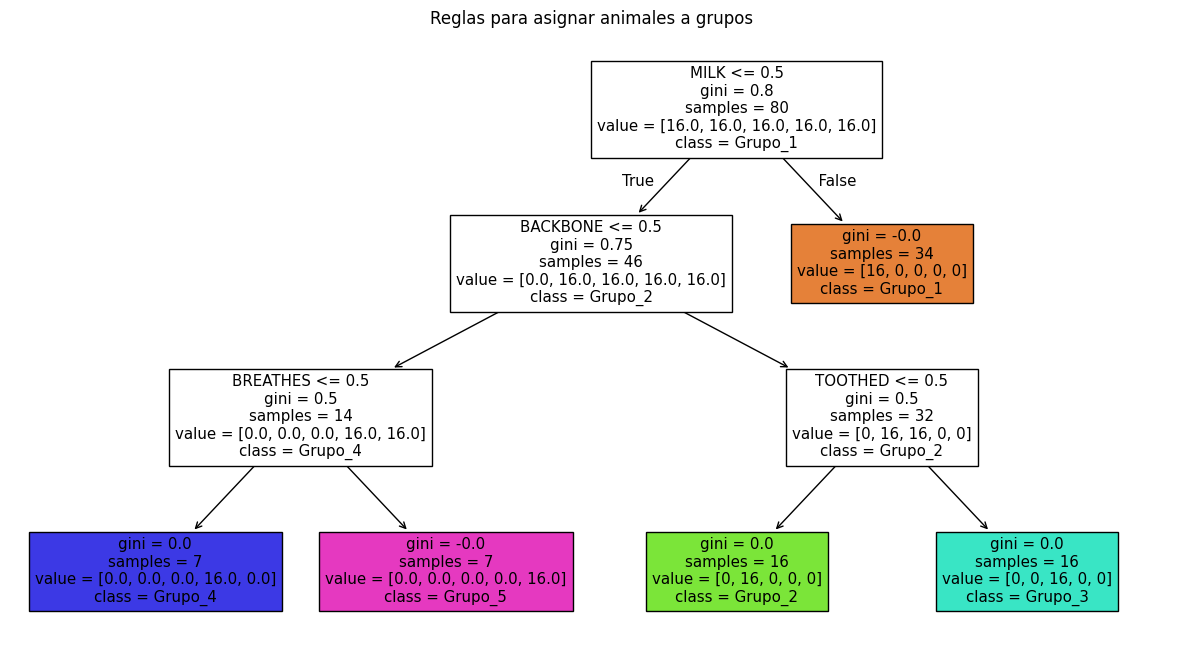

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Entrenar árbol para describir clusters encontrados
tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

# Visualizar reglas
plt.figure(figsize=(15, 8))
plot_tree(tree, feature_names=X.columns,
          class_names=[f'Grupo_{i + 1}' for i in range(6)],
          filled=True)

plt.title("Reglas para asignar animales a grupos")

# Evaluación

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

### Clasificación

In [ ]:
from sklearn.preprocessing import label_binarize

y_pred_dt = tree.predict(X_test)
y_prob_dt = tree.predict_proba(X_test)

print("Árbol de Decisión - Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_dt))
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_dt))

Árbol de Decisión - Matriz de Confusión:
[[10  0  0  0  0  0]
 [ 0  3  0  0  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  1  1  0]
 [ 0  0  0  0  0  1]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       0.00      0.00      0.00         0
           5       1.00      0.50      0.67         2
           6       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.83      0.75      0.78        21
weighted avg       1.00      0.95      0.97        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Agrupamiento

Se pudo evaluar el comportamiento de los objetivos definidos en las etapas de entendimiento del negocio.

Se aplicaron tres métodos de agrupamiento: Jerárquico, DBSCAN y K-means, comparando sus resultados mediante el índice de silueta como métrica principal de cohesión y separación de clústeres.

Los tres modelos alcanzaron valores satisfactorios de silueta, cumpliendo con los criterios de éxito establecidos.

Sin embargo, se seleccionó el método jerárquico como resultado final por su mayor interpretabilidad y capacidad de representar visualmente las relaciones entre los grupos mediante dendrogramas, lo que facilita la comprensión de los patrones por parte de los investigadores y la posterior asignación de especialistas.

### Conclusión

En consecuencia, se considera que los objetivos de negocio y de minería de datos fueron alcanzados.